# Kira Fiyatı Tahmini — İzmir / Buca (Hepsiemlak)

Bu defter, Hepsiemlak'tan alınan kiralık konut ilanlarıyla **Linear Regression** ve **XGBoost** modellerini karşılaştırır.

Akış: veri yükleme → temizleme → keşifsel analiz → modelleme (aynı özellikler, aynı bölünme) → karşılaştırma.

> Defter baştan sona sırayla çalışır ve tekrar çalıştırılabilir (her çalıştırmada ham veriden başlar).

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Veri yükleme

In [2]:
# Önce defterle aynı klasördeki dosyaya bakılır; yoksa (Colab) Drive'dan okunur.
CSV_PATH = Path("hepsiemlak.csv")
if not CSV_PATH.exists():
    from google.colab import drive
    drive.mount("/content/drive")
    CSV_PATH = Path("/content/drive/MyDrive/proje4/hepsiemlak.csv")

df_raw = pd.read_csv(CSV_PATH)
print("Ham veri boyutu:", df_raw.shape)
df_raw.head()

Ham veri boyutu: (687, 9)


,date,category,ad,loc,floor,age,rooms,gross,price
0,26-09-2024,Daire,Menderes Mh. Öğrenciye Kiralık 4+1 130 M2 Tera...,İzmir / Buca / Menderes Mah.,2. Kat,25 Yaşında,4 + 1,130 m²,20.000
1,11-10-2024,Daire,Goldia Yapı'Dan Merkezi Konumda Sıfır Eşyalı K...,İzmir / Buca / Kozağaç Mah.,Ara Kat,4 Yaşında,1 + 1,55 m²,17.500
2,11-10-2024,Daire,Buca Atatürk Mah.'Nde Eşyalı Kiralık Daire (1+1),İzmir / Buca / Atatürk Mah.,En Üst Kat,18 Yaşında,Stüdyo,70 m²,18.500
3,11-10-2024,Daire,İzmir Buca Laleli Mahallesi//Konak Tünelinden ...,İzmir / Buca / Laleli Mah.,4. Kat,25 Yaşında,2 + 1,90 m²,13.000
4,10-10-2024,Daire,Kuruluş Emlaktan Site İçi Kiralık 2+1 130m2 Daire,İzmir / Buca / Mustafa Kemal Mah.,Ara Kat,4 Yaşında,2 + 1,130 m²,29.500


## 2. Veri temizleme

Ham veride tüm sütunlar metin (`"25 Yaşında"`, `"130 m²"`, `"4 + 1"`, `"20.000"`). Bunları sayıya çeviriyoruz.

**Önceki sürümden farklar**
- `loc` ve `floor` artık `LabelEncoder` ile sayıya çevrilmiyor. LabelEncoder mahalleleri alfabetik sırayla 0, 1, 2… yapıyor; doğrusal model bunu "sıralı bir büyüklük" sanıyor, oysa mahalle sıralı değil. Mahalle **one-hot** ile, kat ise **sayısal kat + kat tipi** olarak kodlanıyor.
- Oda sayısı `"4 + 1"` biçiminden **oda** ve **salon** olarak ayrı ayrı çıkarılıyor; `"11 + 18"` gibi girdi hataları eksik değer sayılıyor.

In [3]:
def parse_price(x):
    # "20.000" -> 20000 (Türkçe binlik ayracı nokta)
    return float(str(x).replace(".", "").replace(",", "."))

def parse_age(x):
    x = str(x)
    if "Sıfır" in x:
        return 0.0
    m = re.search(r"\d+", x)
    return float(m.group()) if m else np.nan

def parse_gross(x):
    m = re.search(r"\d+", str(x))
    return float(m.group()) if m else np.nan

def parse_rooms(x):
    x = str(x)
    if "Stüdyo" in x:
        return 1.0, 0.0
    m = re.match(r"\s*(\d+)\s*\+\s*(\d+)", x)
    if not m:
        return np.nan, np.nan
    oda, salon = int(m.group(1)), int(m.group(2))
    # "11 + 18", "3 + 11" gibi imkânsız değerler girdi hatasıdır
    if oda > 7 or salon > 3:
        return np.nan, np.nan
    return float(oda), float(salon)

def parse_floor(x):
    x = str(x)
    m = re.match(r"(\d+)\. Kat", x)
    if m:
        return float(m.group(1)), "Numaralı"
    if x in ("Zemin", "Giriş Katı", "Yüksek Giriş", "Bahçe Katı"):
        return 0.0, "Giriş"
    if x in ("Kot 1", "Kot 2", "Yarı Bodrum"):
        return -1.0, "Bodrum"
    if x in ("En Üst Kat", "Çatı Katı", "Teras Katı"):
        return np.nan, "Üst"
    if x == "Ara Kat":
        return np.nan, "Ara"
    return np.nan, "Bilinmiyor"

df = pd.DataFrame({
    "neighborhood": df_raw["loc"].str.split(" / ").str[2].str.strip(),
    "age":   df_raw["age"].map(parse_age),
    "gross": df_raw["gross"].map(parse_gross),
    "price": df_raw["price"].map(parse_price),
})
df[["rooms", "salon"]] = pd.DataFrame(df_raw["rooms"].map(parse_rooms).tolist(), index=df.index)
df[["floor_no", "floor_type"]] = pd.DataFrame(df_raw["floor"].map(parse_floor).tolist(), index=df.index)
df["ad"] = df_raw["ad"]

print("Eksik değerler:")
print(df.drop(columns="ad").isnull().sum())

Eksik değerler:
neighborhood      0
age               0
gross             0
price             0
rooms             2
salon             2
floor_no        121
floor_type        0
dtype: int64


### Aykırı değerler

Fiyat sütununda **günlük kiralık** ilanlar (200–400 TL) ve tek bir **satılık** ilan (2.750.000 TL) var; bunlar aylık kira değil. Kutu grafiği ve `describe()` bunu net gösteriyor. Ortalama ve RMSE'yi bozdukları için modelden önce çıkarıyoruz.

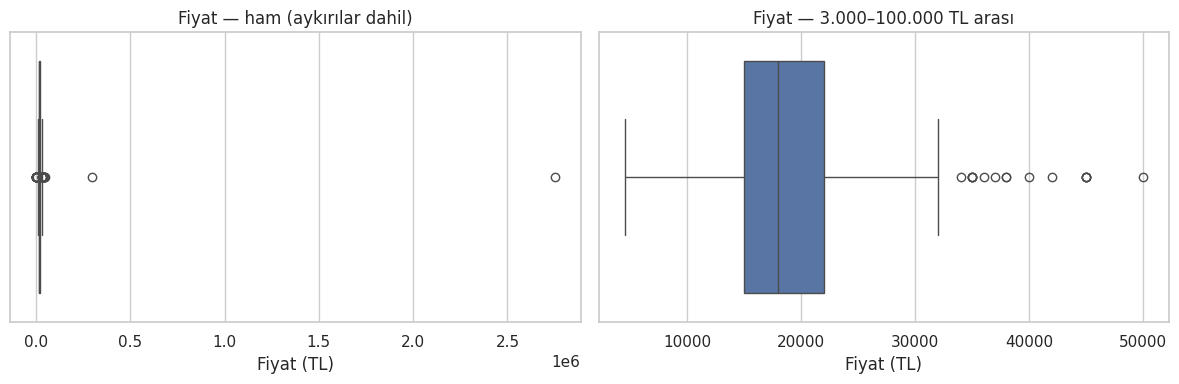

count        687.0
mean       23002.0
std       104918.0
min          200.0
25%        15000.0
50%        18000.0
75%        21750.0
max      2750000.0
Name: price, dtype: float64

Fiyatı 3.000 TL altında olanlar (günlük kiralık):
                                                                 ad  price
10                               Buca Günlük Haftalık Lüks Daireler  200.0
114                      İzmir Buca Günlük Kiralık 1+1 2+1 Daireler  400.0
161                                            Buca Konforun Adresi  200.0
267              Buca Günlük Kiralık Rezidans 7/24 Güvenli Hijyenik  300.0
303  1+1 Ve 2+1 Lüks Apart Daireler - Konforlu Ve Lüks Günlük Evler  400.0
451          İzmir Bucada Konforlu Günlük Haftalık Kiralık Daireler  400.0
468                           Buca Hasan Ağa Bahçesi Günlük Kiralık  350.0
521                                        Ultra Lüks Kiralık Evler  300.0
535               Tınaztepe Hastahanesi Yakını Günlük Lüks Daireler  200.0
547            Günl

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["price"], ax=axes[0]); axes[0].set_title("Fiyat — ham (aykırılar dahil)")
axes[0].set_xlabel("Fiyat (TL)")
sns.boxplot(x=df.loc[df["price"].between(3_000, 100_000), "price"], ax=axes[1])
axes[1].set_title("Fiyat — 3.000–100.000 TL arası"); axes[1].set_xlabel("Fiyat (TL)")
plt.tight_layout(); plt.show()

print(df["price"].describe().round(0))
print("\nFiyatı 3.000 TL altında olanlar (günlük kiralık):")
print(df.loc[df["price"] < 3_000, ["ad", "price"]].to_string())
print("\nFiyatı 100.000 TL üstünde olanlar:")
print(df.loc[df["price"] > 100_000, ["ad", "price"]].to_string())

In [5]:
n0 = len(df)
df = df[df["price"].between(3_000, 100_000)]          # günlük kiralık + satılık ilanlar
n1 = len(df)
df = df.drop_duplicates(subset=["ad", "neighborhood", "age", "gross", "price",
                                "rooms", "salon", "floor_no", "floor_type"])
n2 = len(df)
df = df.drop(columns="ad").reset_index(drop=True)
print(f"Başlangıç: {n0} | fiyat filtresi sonrası: {n1} | tekrar eden ilanlar sonrası: {n2}")
df.describe().round(1)

Başlangıç: 687 | fiyat filtresi sonrası: 674 | tekrar eden ilanlar sonrası: 672


,age,gross,price,rooms,salon,floor_no
count,672.0,672.0,672.0,670.0,670.0,560.0
mean,10.7,90.7,18931.2,1.9,1.0,2.1
std,9.2,37.5,5605.2,0.9,0.2,1.9
min,0.0,25.0,4500.0,1.0,0.0,-1.0
25%,4.0,55.0,15000.0,1.0,1.0,1.0
50%,7.0,85.0,18000.0,2.0,1.0,2.0
75%,16.0,125.0,22000.0,3.0,1.0,3.0
max,45.0,285.0,50000.0,4.0,2.0,12.0


## 3. Keşifsel analiz

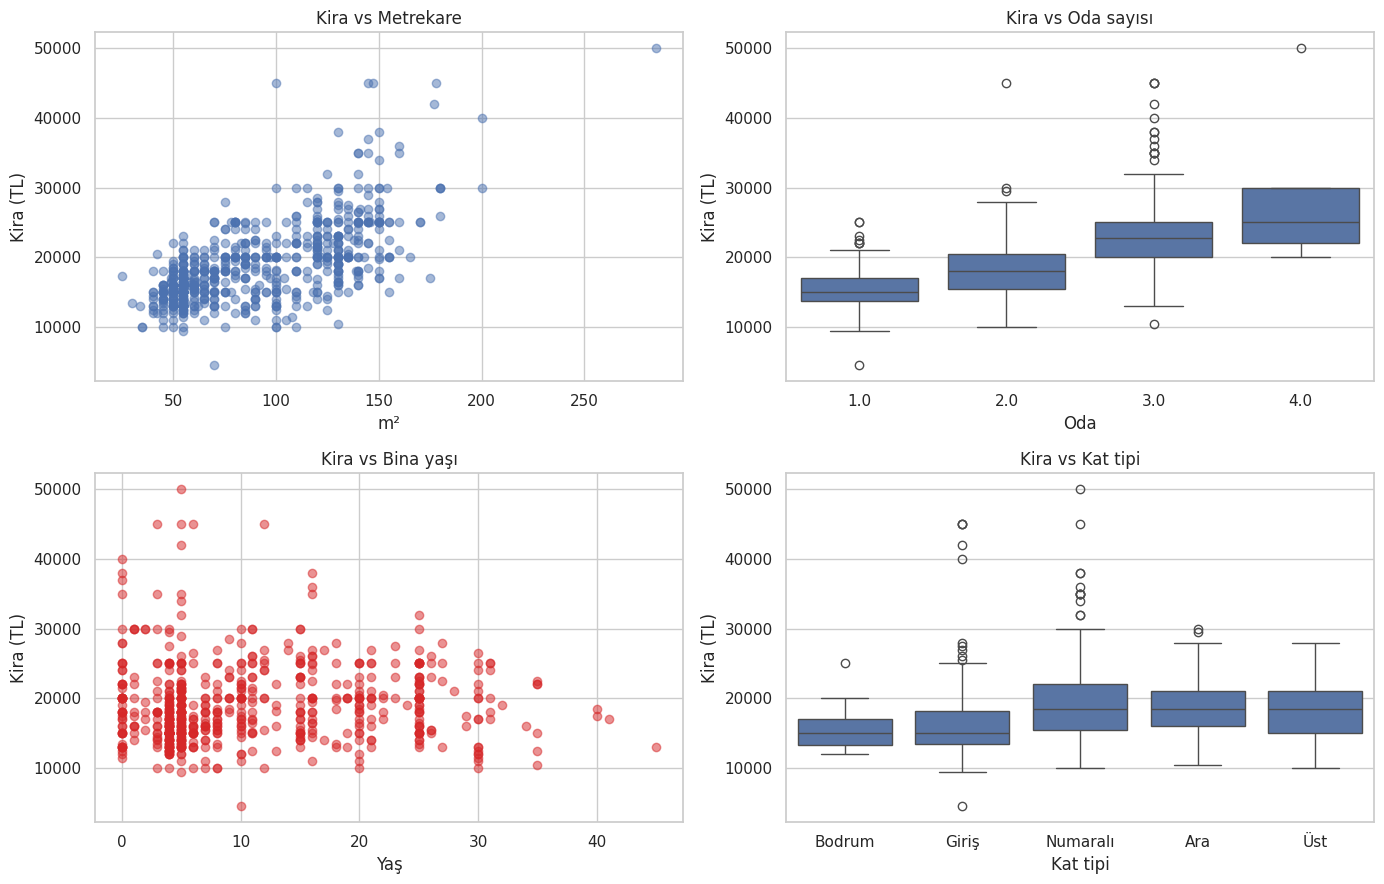

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(df["gross"], df["price"], alpha=0.5)
axes[0, 0].set_title("Kira vs Metrekare"); axes[0, 0].set_xlabel("m²"); axes[0, 0].set_ylabel("Kira (TL)")

sns.boxplot(x="rooms", y="price", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Kira vs Oda sayısı"); axes[0, 1].set_xlabel("Oda"); axes[0, 1].set_ylabel("Kira (TL)")

axes[1, 0].scatter(df["age"], df["price"], alpha=0.5, color="tab:red")
axes[1, 0].set_title("Kira vs Bina yaşı"); axes[1, 0].set_xlabel("Yaş"); axes[1, 0].set_ylabel("Kira (TL)")

sns.boxplot(x="floor_type", y="price", data=df, ax=axes[1, 1],
            order=["Bodrum", "Giriş", "Numaralı", "Ara", "Üst"])
axes[1, 1].set_title("Kira vs Kat tipi"); axes[1, 1].set_xlabel("Kat tipi"); axes[1, 1].set_ylabel("Kira (TL)")

plt.tight_layout(); plt.show()

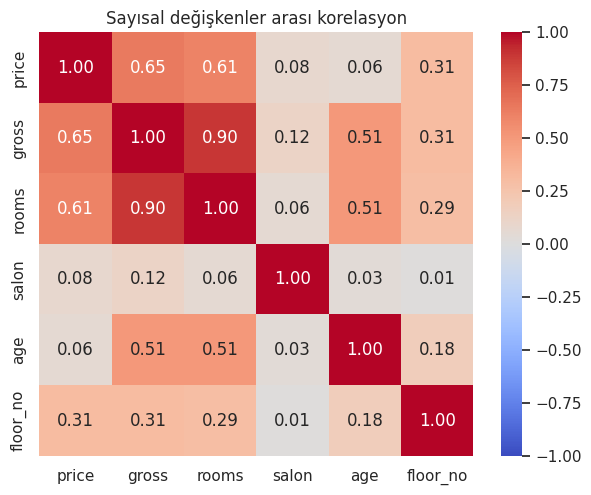

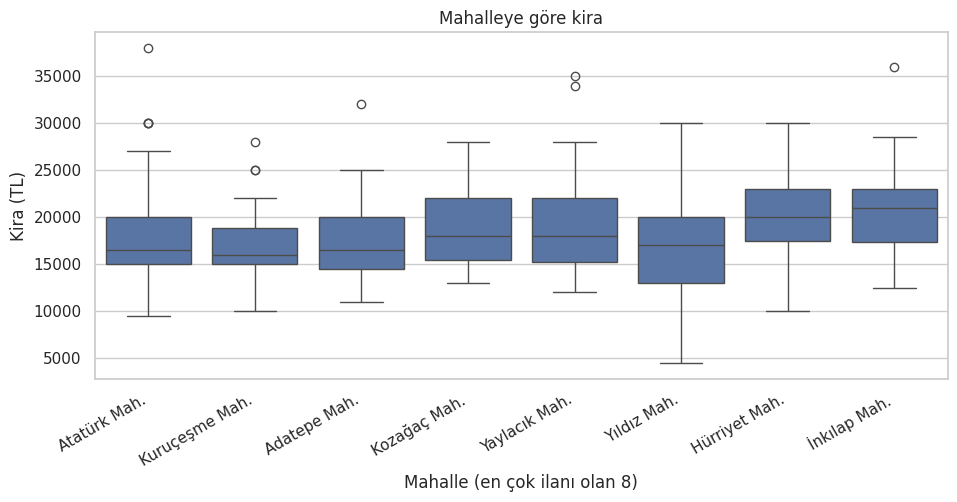

In [7]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(df[["price", "gross", "rooms", "salon", "age", "floor_no"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Sayısal değişkenler arası korelasyon"); plt.show()

top = df["neighborhood"].value_counts().head(8).index
plt.figure(figsize=(11, 4.5))
sns.boxplot(x="neighborhood", y="price", data=df[df["neighborhood"].isin(top)], order=top)
plt.xticks(rotation=30, ha="right"); plt.xlabel("Mahalle (en çok ilanı olan 8)"); plt.ylabel("Kira (TL)")
plt.title("Mahalleye göre kira"); plt.show()

## 4. Modelleme

İki model de **aynı özellikler**, **aynı train/test bölünmesi** ve **aynı ön işleme** ile eğitilir (önceki sürümde modeller farklı özellik kümeleri ve farklı bölünmelerle eğitilip tek tabloda kıyaslanıyordu, bu adil değildi).

- Sayısal özellikler: `gross, rooms, salon, age, floor_no` — eksikler medyanla doldurulur
- Kategorik özellikler: `neighborhood, floor_type` — one-hot (5'ten az ilanı olan mahalleler tek grupta toplanır)
- Test seti (%20) modele hiç gösterilmez; hiperparametre seçimi yalnızca eğitim seti içinde 5-katlı çapraz doğrulama ile yapılır.
- 680 civarı satır az olduğu için tek bir test bölünmesine ek olarak tüm veri üzerinde 5-katlı CV sonuçları da verilir.

In [8]:
num_cols = ["gross", "rooms", "salon", "age", "floor_no"]
cat_cols = ["neighborhood", "floor_type"]

def make_preprocessor():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5), cat_cols),
    ])

X = df[num_cols + cat_cols]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Eğitim:", X_train.shape, "| Test:", X_test.shape)

lr = Pipeline([("prep", make_preprocessor()), ("model", LinearRegression())])

xgb_base = Pipeline([("prep", make_preprocessor()),
                     ("model", XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE,
                                            n_jobs=1))])
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(xgb_base, param_grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
grid.fit(X_train, y_train)
xgb = grid.best_estimator_
print("XGBoost en iyi parametreler:", grid.best_params_)

lr.fit(X_train, y_train)

Eğitim: (537, 7) | Test: (135, 7)


XGBoost en iyi parametreler: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [9]:
def evaluate(name, model):
    pred = model.predict(X_test)
    return {
        "Model": name,
        "RMSE (TL)": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE (TL)": mean_absolute_error(y_test, pred),
        "MAPE (%)": 100 * mean_absolute_percentage_error(y_test, pred),
        "R²": r2_score(y_test, pred),
    }

test_results = pd.DataFrame([evaluate("Linear Regression", lr), evaluate("XGBoost", xgb)]).set_index("Model")
print("--- Test seti sonuçları (%20) ---")
display(test_results.round(3))

# Tüm veri üzerinde 5-katlı CV (daha güvenilir tahmin)
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error",
           "mape": "neg_mean_absolute_percentage_error", "r2": "r2"}
rows = []
for name, m in [("Linear Regression", lr), ("XGBoost", xgb)]:
    s = cross_validate(m, X, y, cv=cv, scoring=scoring)
    rows.append({"Model": name,
                 "RMSE (TL)": -s["test_rmse"].mean(), "RMSE std": s["test_rmse"].std(),
                 "MAE (TL)": -s["test_mae"].mean(),
                 "MAPE (%)": -100 * s["test_mape"].mean(),
                 "R²": s["test_r2"].mean()})
cv_results = pd.DataFrame(rows).set_index("Model")
print("\n--- 5-katlı çapraz doğrulama (tüm veri) ---")
display(cv_results.round(3))

--- Test seti sonuçları (%20) ---


,RMSE (TL),MAE (TL),MAPE (%),R²
Model,,,,
Linear Regression,3394.067,2493.894,12.957,0.649
XGBoost,3397.391,2351.124,12.260,0.648



--- 5-katlı çapraz doğrulama (tüm veri) ---


,RMSE (TL),RMSE std,MAE (TL),MAPE (%),R²
Model,,,,,
Linear Regression,3761.405,263.491,2713.853,14.881,0.536
XGBoost,3732.399,274.064,2649.489,14.450,0.539


## 5. Görselleştirme

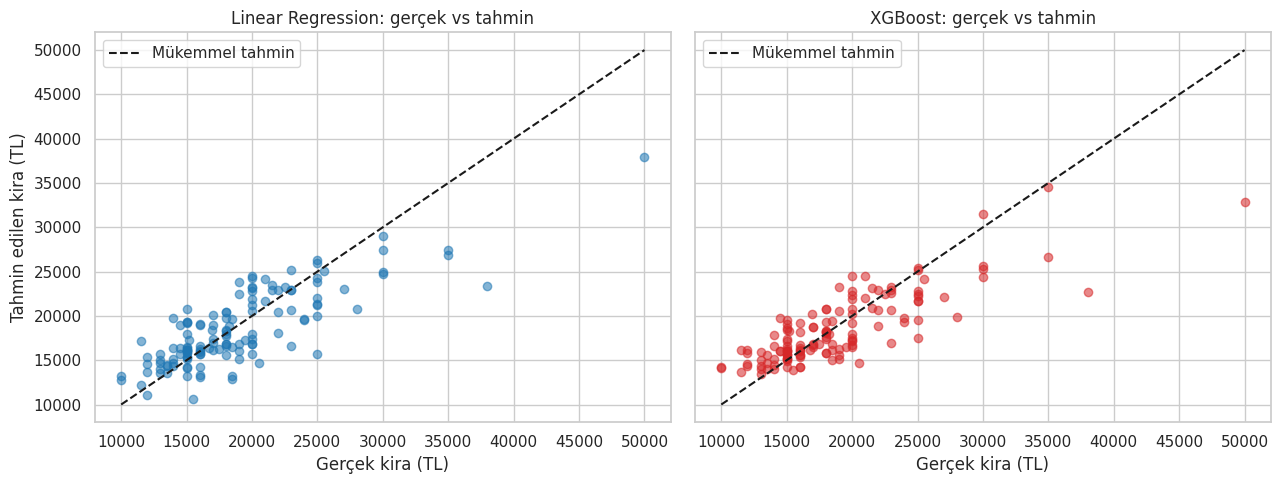

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
lims = [y_test.min(), y_test.max()]
for ax, (name, model, color) in zip(axes, [("Linear Regression", lr, "tab:blue"), ("XGBoost", xgb, "tab:red")]):
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, alpha=0.55, color=color)
    ax.plot(lims, lims, "k--", label="Mükemmel tahmin")
    ax.set_title(f"{name}: gerçek vs tahmin"); ax.set_xlabel("Gerçek kira (TL)"); ax.legend()
axes[0].set_ylabel("Tahmin edilen kira (TL)")
plt.tight_layout(); plt.show()

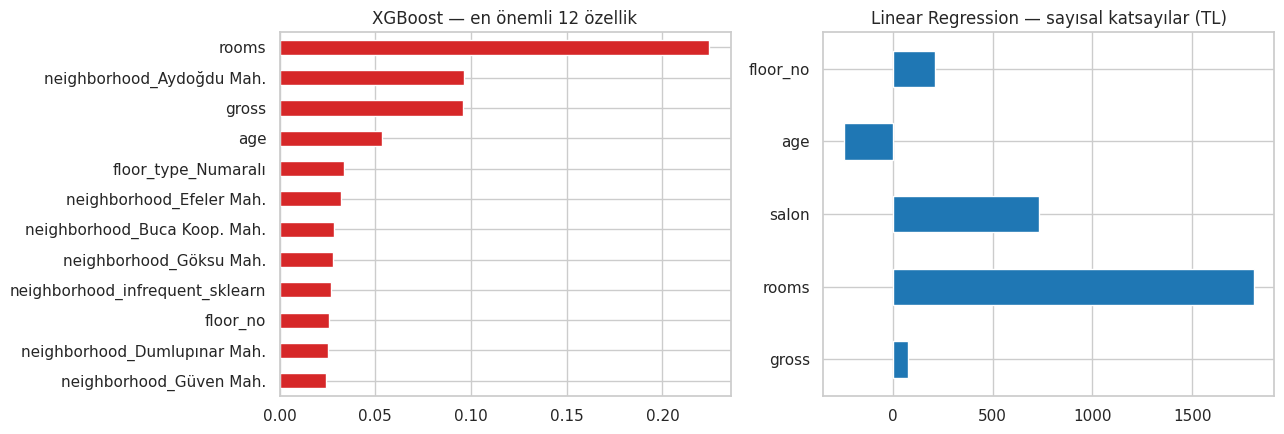

LR katsayıları (1 birim artışın kira üzerindeki etkisi, diğerleri sabitken):
gross         74.5
rooms       1807.0
salon        730.7
age         -245.8
floor_no     209.8


In [11]:
# XGBoost özellik önemleri (one-hot sütunları dahil)
prep = xgb.named_steps["prep"]
names = prep.get_feature_names_out()
imp = pd.Series(xgb.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(12)
imp.index = [n.replace("num__", "").replace("cat__", "") for n in imp.index]

# Linear Regression: sayısal katsayılar (TL cinsinden etki)
coef = pd.Series(lr.named_steps["model"].coef_, index=lr.named_steps["prep"].get_feature_names_out())
coef_num = coef[[c for c in coef.index if c.startswith("num__")]]
coef_num.index = [c.replace("num__", "") for c in coef_num.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
imp[::-1].plot.barh(ax=axes[0], color="tab:red"); axes[0].set_title("XGBoost — en önemli 12 özellik")
coef_num.plot.barh(ax=axes[1], color="tab:blue"); axes[1].set_title("Linear Regression — sayısal katsayılar (TL)")
plt.tight_layout(); plt.show()

print("LR katsayıları (1 birim artışın kira üzerindeki etkisi, diğerleri sabitken):")
print(coef_num.round(1).to_string())

## 6. Örnek tahmin

In [12]:
ornek = pd.DataFrame([{
    "gross": 100, "rooms": 3, "salon": 1, "age": 5, "floor_no": 3,
    "neighborhood": "Atatürk Mah.", "floor_type": "Numaralı",
}])
print("Atatürk Mah., 100 m², 3+1, 5 yaşında, 3. kat için tahmini kira:")
print(f"  Linear Regression: {lr.predict(ornek)[0]:,.0f} TL")
print(f"  XGBoost:           {xgb.predict(ornek)[0]:,.0f} TL")

Atatürk Mah., 100 m², 3+1, 5 yaşında, 3. kat için tahmini kira:
  Linear Regression: 22,832 TL
  XGBoost:           21,979 TL


## 7. Sonuç

In [13]:
best = cv_results["RMSE (TL)"].idxmin()
other = [m for m in cv_results.index if m != best][0]
b, o = cv_results.loc[best], cv_results.loc[other]
fark = o["RMSE (TL)"] - b["RMSE (TL)"]
belirsizlik = max(b["RMSE std"], o["RMSE std"])

print(f"Çapraz doğrulama RMSE: Linear Regression {cv_results.loc['Linear Regression', 'RMSE (TL)']:,.0f} TL | "
      f"XGBoost {cv_results.loc['XGBoost', 'RMSE (TL)']:,.0f} TL")
print(f"Çapraz doğrulama MAPE: Linear Regression %{cv_results.loc['Linear Regression', 'MAPE (%)']:.1f} | "
      f"XGBoost %{cv_results.loc['XGBoost', 'MAPE (%)']:.1f}")
print()
if fark > belirsizlik:
    print(f"{best}, {other} modelinden belirgin şekilde daha iyi (fark {fark:,.0f} TL, katlar arası sapma {belirsizlik:,.0f} TL).")
else:
    print(f"İki model pratikte eşdeğer: RMSE farkı ({fark:,.0f} TL), katlar arası sapmadan ({belirsizlik:,.0f} TL) küçük.")
    print("Bu veri setinde (az sayıda özellik, ~670 ilan) XGBoost'un esnekliği doğrusal modele belirgin bir üstünlük sağlamıyor;")
    print("bu durumda daha basit ve yorumlanabilir olan Linear Regression tercih edilebilir.")
print()
print("Not: Veri yalnızca İzmir/Buca'daki ~670 ilandan oluşuyor; sonuçlar başka şehir/ilçelere genellenemez.")

Çapraz doğrulama RMSE: Linear Regression 3,761 TL | XGBoost 3,732 TL
Çapraz doğrulama MAPE: Linear Regression %14.9 | XGBoost %14.4

İki model pratikte eşdeğer: RMSE farkı (29 TL), katlar arası sapmadan (274 TL) küçük.
Bu veri setinde (az sayıda özellik, ~670 ilan) XGBoost'un esnekliği doğrusal modele belirgin bir üstünlük sağlamıyor;
bu durumda daha basit ve yorumlanabilir olan Linear Regression tercih edilebilir.

Not: Veri yalnızca İzmir/Buca'daki ~670 ilandan oluşuyor; sonuçlar başka şehir/ilçelere genellenemez.
